In [ ]:
#  بسم الله الرحمن الرحیم  

In [ ]:
#  کد ایجاد انبوه

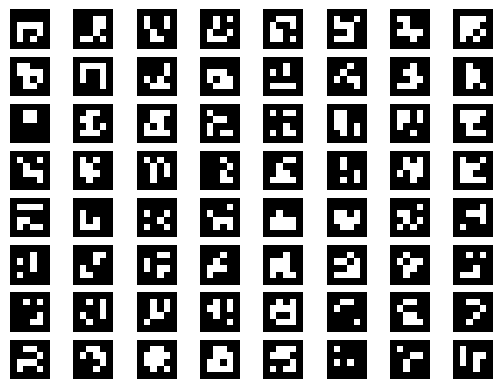

In [3]:
import cv2 
import numpy as np
import cv2.aruco as aruco
import matplotlib.pyplot as plt
import matplotlib as mpl


# Load the predefined dictionary DICT_7X7_100
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_100) #size is 4 by 4 and number is 50 - faster
marker_size = 200


fig = plt.figure()
nx = 8
ny = 8
for marker_id in range(1, nx*ny+1):
    ax = fig.add_subplot(ny,nx, marker_id)
    Marker_zero = np.zeros((marker_size, marker_size), dtype=np.uint8) #
    markerImage = cv2.aruco.generateImageMarker(aruco_dict,marker_id, marker_size,Marker_zero, 1) #marker_size is the number of pixels
       
    plt.imshow(markerImage, cmap = mpl.cm.gray, interpolation = "nearest")
    ax.axis("off")

plt.savefig("markers.jpeg")
plt.show()


In [ ]:
# توابع

In [4]:
# تابع یک _ شناسایی نشانگر
def marker_detect(image):
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_100)
    parameters = cv2.aruco.DetectorParameters()

    # Create the ArUco detector
    detector = cv2.aruco.ArucoDetector(aruco_dict, parameters) #********
    # Detect the markers
    corners, ids, rejected = detector.detectMarkers(gray) #***
    # Print the detected markers
    #print("Detected markers:", corners, ids) # print all data <-----
    if ids is not None:
        cv2.aruco.drawDetectedMarkers(image, corners, ids)
        cv2.imshow('Detected Markers', image)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
    
    return corners, ids

In [ ]:
#  تشخیص گوشه های نشانگر

In [5]:
# تابع دو _ #  تشخیص گوشه های نشانگر
def marker_corner(corners,ids):
    # verify *at least* one ArUco marker was detected
    if len(corners) > 0:
    # flatten the ArUco IDs list
        ids = ids.flatten()
        print(ids)
        corners_dic={} ; i=0
        # loop over the detected ArUCo corners
        for corner in corners:
            # extract the marker corners (which are always returned in
            # top-left, top-right, bottom-right, and bottom-left order)
            print(corner)
            topLeft = corner[0][0]
            topRight= corner[0][1]
            bottomRight=corner[0][2]
            bottomLeft=corner[0][3]
            print(topLeft,topRight,bottomRight,bottomLeft)
            # convert each of the (x, y)-coordinate pairs to integers
            topRight = (int(topRight[0]), int(topRight[1]))
            bottomRight = (int(bottomRight[0]), int(bottomRight[1]))
            bottomLeft = (int(bottomLeft[0]), int(bottomLeft[1]))
            topLeft = (int(topLeft[0]), int(topLeft[1]))
            print(topLeft,topRight,bottomRight,bottomLeft)
            # (307, 118) (307, 158) (227, 160) (231, 121) = example
            corners_dic[ids[i]]=(topLeft,topRight,bottomRight,bottomLeft)
            i=i+1
            
    return corners_dic

In [5]:
# تابع سوم _ نمایش نشانگرها 
def draw_marker(image,corners_dic):
    # draw the bounding box of the ArUCo detection
    for ids,corner in corners_dic.items():
        topLeft,topRight,bottomRight,bottomLeft=corner
        cv2.line(image, topLeft, topRight, (0, 255, 0), 2)
        cv2.line(image, topRight, bottomRight, (0, 255, 0), 2)
        cv2.line(image, bottomRight, bottomLeft, (0, 255, 0), 2)
        cv2.line(image, bottomLeft, topLeft, (0, 255, 0), 2)
        # compute and draw the center (x, y)-coordinates of the ArUco
        # marker
        cX = int((topLeft[0] + bottomRight[0]) / 2.0)
        cY = int((topLeft[1] + bottomRight[1]) / 2.0)
        cv2.circle(image, (cX, cY), 4, (0, 0, 255), -1)
        # draw the ArUco marker ID on the image
        cv2.putText(image, str(ids),
            (topLeft[0], topLeft[1] - 15), cv2.FONT_HERSHEY_SIMPLEX,
            0.5, (0, 0, 255), 2)
    
    print("[INFO] ArUco marker ID: {}".format(ids))
    # show the output image
    cv2.imshow("Image", image)
    cv2.waitKey(0)

In [8]:
# تابع اصلی 
# ==================  MAIN ================
import cv2
import numpy as np
import cv2.aruco as aruco
import matplotlib.pyplot as plt
import matplotlib as mpl

# Load the image
image = cv2.imread('markers_1.jpg') # C:/Users/my_name_user_in_windowd/markers_1.jpeg'
cv2.imshow("ArUco Marker", image);cv2.waitKey(0);cv2.destroyAllWindows()

corners, ids = marker_detect(image)
corners_dic = marker_corner(corners,ids)
print(corners_dic)

draw_marker(image,corners_dic)

[61 53 60 52 44 36 59 51 35 43 58 50 42 34 57 49 41 33]
[[[191. 364.]
  [186. 433.]
  [ 85. 432.]
  [ 98. 365.]]]
[191. 364.] [186. 433.] [ 85. 432.] [ 98. 365.]
(191, 364) (186, 433) (85, 432) (98, 365)
[[[306. 362.]
  [308. 428.]
  [208. 432.]
  [211. 366.]]]
[306. 362.] [308. 428.] [208. 432.] [211. 366.]
(306, 362) (308, 428) (208, 432) (211, 366)
[[[200. 269.]
  [194. 327.]
  [105. 326.]
  [116. 269.]]]
[200. 269.] [194. 327.] [105. 326.] [116. 269.]
(200, 269) (194, 327) (105, 326) (116, 269)
[[[307. 268.]
  [306. 324.]
  [214. 325.]
  [221. 268.]]]
[307. 268.] [306. 324.] [214. 325.] [221. 268.]
(307, 268) (306, 324) (214, 325) (221, 268)
[[[413. 265.]
  [420. 322.]
  [328. 324.]
  [325. 269.]]]
[413. 265.] [420. 322.] [328. 324.] [325. 269.]
(413, 265) (420, 322) (328, 324) (325, 269)
[[[520. 264.]
  [533. 322.]
  [443. 323.]
  [435. 265.]]]
[520. 264.] [533. 322.] [443. 323.] [435. 265.]
(520, 264) (533, 322) (443, 323) (435, 265)
[[[207. 190.]
  [202. 236.]
  [122. 237.]
  [1

In [1]:
# Webcam ArUco marker detection
import cv2
import time
import numpy as np
import cv2.aruco as aruco

# Initialize webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

# Detection settings
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_100)
parameters = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(aruco_dict, parameters)

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Error: Could not read frame.")
            break

        output_frame = frame.copy()
        gray = cv2.cvtColor(output_frame, cv2.COLOR_BGR2GRAY)

        corners, ids, rejected = detector.detectMarkers(gray)

        if ids is not None:
            cv2.aruco.drawDetectedMarkers(output_frame, corners, ids)

            ids = ids.flatten()
            for i, corner in enumerate(corners):
                topLeft, topRight, bottomRight, bottomLeft = corner[0]
                topLeft = (int(topLeft[0]), int(topLeft[1]))
                topRight = (int(topRight[0]), int(topRight[1]))
                bottomRight = (int(bottomRight[0]), int(bottomRight[1]))
                bottomLeft = (int(bottomLeft[0]), int(bottomLeft[1]))

                cv2.line(output_frame, topLeft, topRight, (0, 255, 0), 2)
                cv2.line(output_frame, topRight, bottomRight, (0, 255, 0), 2)
                cv2.line(output_frame, bottomRight, bottomLeft, (0, 255, 0), 2)
                cv2.line(output_frame, bottomLeft, topLeft, (0, 255, 0), 2)

                cX = int((topLeft[0] + bottomRight[0]) / 2.0)
                cY = int((topLeft[1] + bottomRight[1]) / 2.0)
                cv2.circle(output_frame, (cX, cY), 4, (0, 0, 255), -1)

                cv2.putText(output_frame, str(ids[i]), (topLeft[0], topLeft[1] - 15),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

        cv2.imshow("Webcam Feed", output_frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

except KeyboardInterrupt:
    print("Capture stopped by user.")

cap.release()
cv2.destroyAllWindows()

Capture stopped by user.
